In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mysql.connector
import os

DB_CONFIG = {
    "host": "localhost",
    "user": "root",
    "password": "YOUR_PASSWORD",
    "database": "lowes_db",
}

def run_query(sql):
    # Run a SQL query and return a DataFrame
    conn = mysql.connector.connect(**DB_CONFIG)
    df = pd.read_sql(sql, conn)
    conn.close()
    return df

# lets see if it works
run_query("SELECT COUNT(*) AS n FROM clean_financials")

/var/folders/32/xg3kzz254ng1l1tfj5yxt7k40000gn/T/ipykernel_47339/4261944220.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


,n
0,15


In [12]:
df_annual = run_query("""
    SELECT fiscal_year, net_sales_mm, gross_margin_pct,
           operating_margin_pct, net_margin_pct, diluted_earn_per_share,
           store_count, revenue_per_store_mm, inventory_turnover,
           capex_intensity_pct, revenue_per_sqft
    FROM clean_financials
    WHERE fiscal_quarter = 'FY'
    ORDER BY fiscal_year DESC
""")
df_annual

/var/folders/32/xg3kzz254ng1l1tfj5yxt7k40000gn/T/ipykernel_47339/4261944220.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


,fiscal_year,net_sales_mm,gross_margin_pct,operating_margin_pct,net_margin_pct,diluted_earn_per_share,store_count,revenue_per_store_mm,inventory_turnover,capex_intensity_pct,revenue_per_sqft
0,2025,86286.0,33.48,11.77,7.71,11.85,1759,49.05,3.32,2.56,440.23
1,2024,83674.0,33.32,12.51,8.31,12.23,1748,47.87,3.21,2.30,429.10
2,2023,86377.0,33.39,13.38,8.94,13.20,1746,49.47,3.41,2.27,442.96


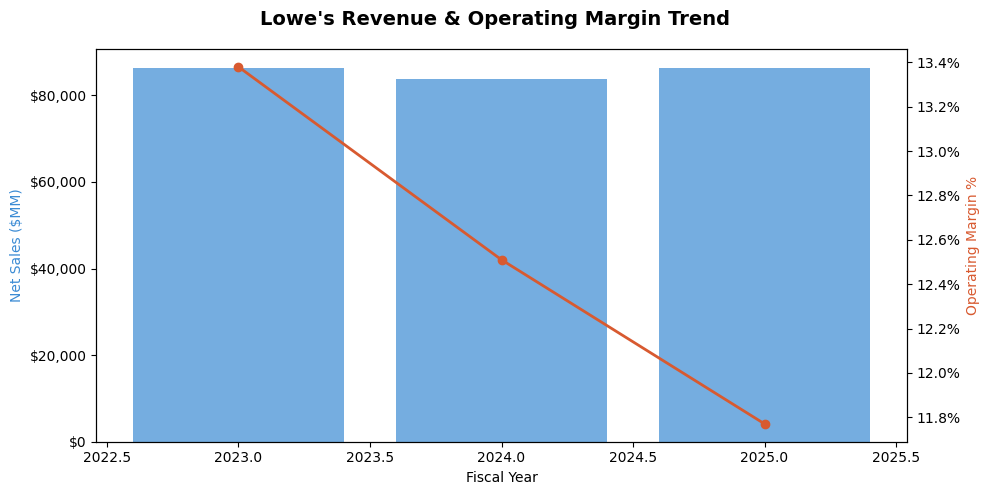

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(df_annual["fiscal_year"], df_annual["net_sales_mm"],
        color="#3B8BD4", alpha=0.7, label="Net Sales ($MM)")
ax1.set_xlabel("Fiscal Year")
ax1.set_ylabel("Net Sales ($MM)", color="#3B8BD4")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax2 = ax1.twinx()
ax2.plot(df_annual["fiscal_year"], df_annual["operating_margin_pct"],
         color="#D85A30", marker="o", linewidth=2, label="Operating Margin %")
ax2.set_ylabel("Operating Margin %", color="#D85A30")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

fig.suptitle("Lowe's Revenue & Operating Margin Trend", fontsize=14, fontweight="bold")
fig.tight_layout()
os.makedirs("outputs", exist_ok=True) # this needs to be added for operating system to create output 
plt.savefig("outputs/revenue_margin_trend.png", dpi=150, bbox_inches="tight")
plt.show()

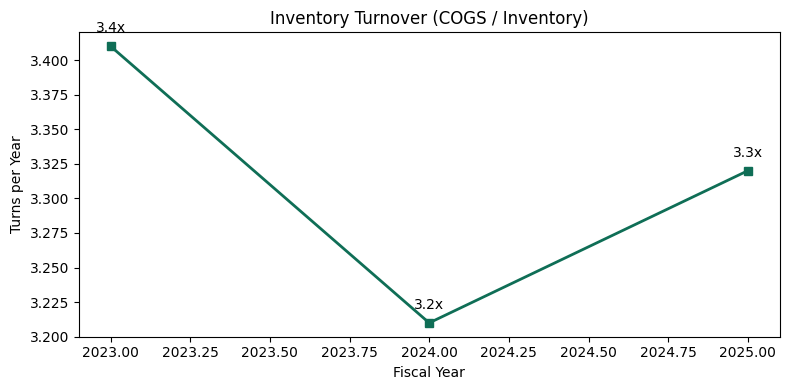

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_annual["fiscal_year"], df_annual["inventory_turnover"],
        marker="s", linewidth=2, color="#0F6E56")
ax.set_title("Inventory Turnover (COGS / Inventory)")
ax.set_ylabel("Turns per Year")
ax.set_xlabel("Fiscal Year")

for i, row in df_annual.iterrows():
    if pd.notna(row["inventory_turnover"]):
        ax.annotate(f'{row["inventory_turnover"]:.1f}x',
                    (row["fiscal_year"], row["inventory_turnover"]),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("outputs/inventory_turnover.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
df_stores = run_query("SELECT * FROM clean_reviews")
print(f"Stores: {len(df_stores)}, Total reviews: {df_stores['review_count'].sum():,}")
df_stores.describe()

Stores: 118, Total reviews: 211,049


/var/folders/32/xg3kzz254ng1l1tfj5yxt7k40000gn/T/ipykernel_47339/4261944220.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


,id,latitude,longitude,overall_rating,review_count
count,118.000000,118.000000,118.000000,118.000000,118.000000
mean,59.500000,35.520209,-75.779698,4.133898,1788.550847
std,34.207699,0.561587,25.173731,0.119986,535.276087
min,1.000000,33.955175,-83.980580,3.800000,52.000000
25%,30.250000,35.176223,-80.864280,4.100000,1495.750000
50%,59.500000,35.590875,-79.819376,4.100000,1820.500000
75%,88.750000,35.963194,-78.543875,4.200000,2211.000000
max,118.000000,36.485641,80.102825,4.600000,3016.000000


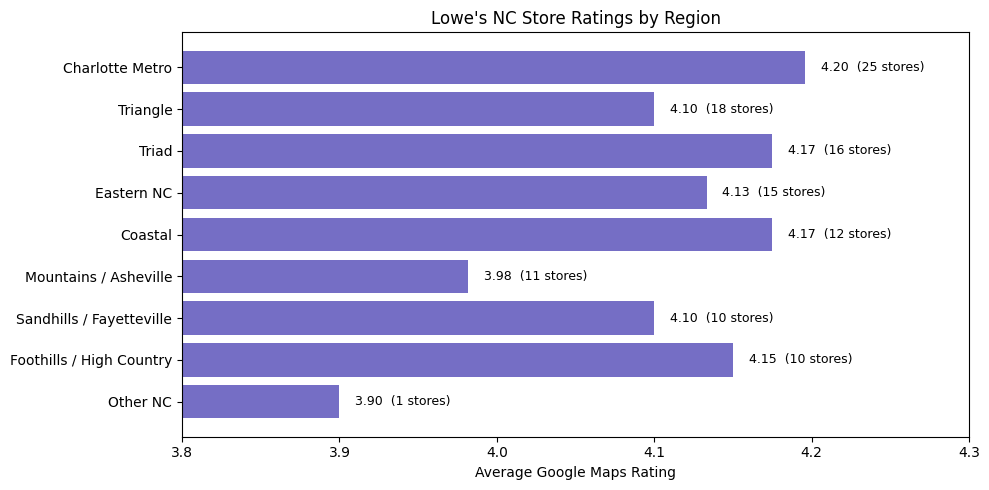

In [17]:
region_stats = df_stores.groupby("nc_region").agg(
    stores=("store_number", "count"),
    avg_rating=("overall_rating", "mean"),
    total_reviews=("review_count", "sum"),
).sort_values("stores", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(region_stats.index, region_stats["avg_rating"],
               color="#534AB7", alpha=0.8)
ax.set_xlim(3.8, 4.3)
ax.set_xlabel("Average Google Maps Rating")
ax.set_title("Lowe's NC Store Ratings by Region")

for bar, (_, row) in zip(bars, region_stats.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{row["avg_rating"]:.2f}  ({int(row["stores"])} stores)',
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/rating_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

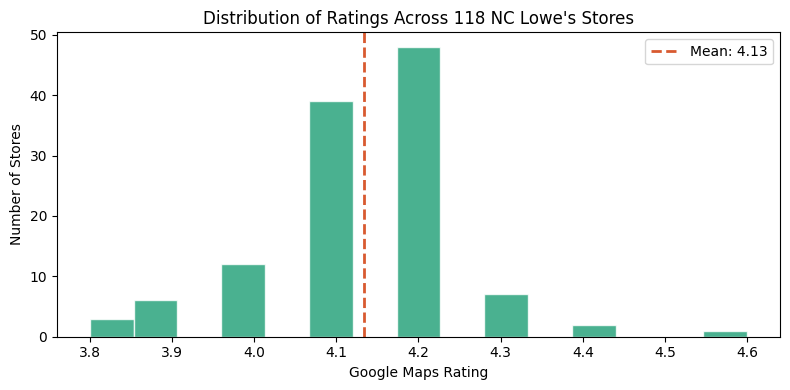

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_stores["overall_rating"], bins=15, color="#1D9E75",
        edgecolor="white", alpha=0.8)
ax.set_xlabel("Google Maps Rating")
ax.set_ylabel("Number of Stores")
ax.set_title(f"Distribution of Ratings Across {len(df_stores)} NC Lowe's Stores")
ax.axvline(df_stores["overall_rating"].mean(), color="#D85A30",
           linestyle="--", linewidth=2,
           label=f'Mean: {df_stores["overall_rating"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig("outputs/rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
print("=" * 60)
print("LOWE'S NC CROSS-DOMAIN SUMMARY")
print("=" * 60)

latest_fy = df_annual[df_annual["fiscal_year"] == df_annual["fiscal_year"].max()].iloc[0]
print(f"\nFinancial (FY{int(latest_fy['fiscal_year'])}):")
print(f"  Revenue: ${latest_fy['net_sales_mm']:,.0f}MM")
print(f"  Operating margin: {latest_fy['operating_margin_pct']:.1f}%")
print(f"  Stores nationwide: {int(latest_fy['store_count']):,}")
print(f"  Revenue/store: ${latest_fy['revenue_per_store_mm']:.1f}MM")

print(f"\nCustomer Sentiment (NC, {len(df_stores)} stores):")
print(f"  Avg rating: {df_stores['overall_rating'].mean():.2f} / 5.0")
print(f"  Total reviews: {df_stores['review_count'].sum():,}")
print(f"  Highest rated region: {region_stats['avg_rating'].idxmax()} "
      f"({region_stats['avg_rating'].max():.2f})")
print(f"  Most reviewed store: {df_stores.loc[df_stores['review_count'].idxmax(), 'city']} "
      f"({df_stores['review_count'].max():,} reviews)")

LOWE'S NC CROSS-DOMAIN SUMMARY

Financial (FY2025):
  Revenue: $86,286MM
  Operating margin: 11.8%
  Stores nationwide: 1,759
  Revenue/store: $49.0MM

Customer Sentiment (NC, 118 stores):
  Avg rating: 4.13 / 5.0
  Total reviews: 211,049
  Highest rated region: Charlotte Metro (4.20)
  Most reviewed store: Fayetteville (3,016 reviews)
